In [26]:
import pandas as pd
import numpy as np

In [27]:
df=pd.read_csv("housing.csv")

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [29]:
df["median_income"]

0        8.3252
1        8.3014
2        7.2574
3        5.6431
4        3.8462
          ...  
20635    1.5603
20636    2.5568
20637    1.7000
20638    1.8672
20639    2.3886
Name: median_income, Length: 20640, dtype: float64

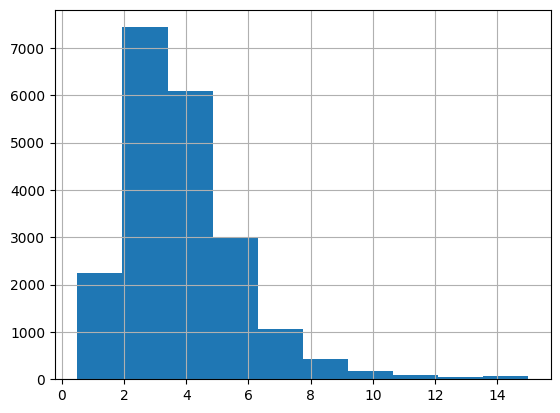

In [30]:
import matplotlib.pyplot as plt

df["median_income"].hist()

plt.show()

In [31]:
df["income_cat"] = pd.cut(df["median_income"],bins=[0., 1.5, 3.0, 4.5, 6., np.inf],labels=[1, 2, 3, 4, 5])

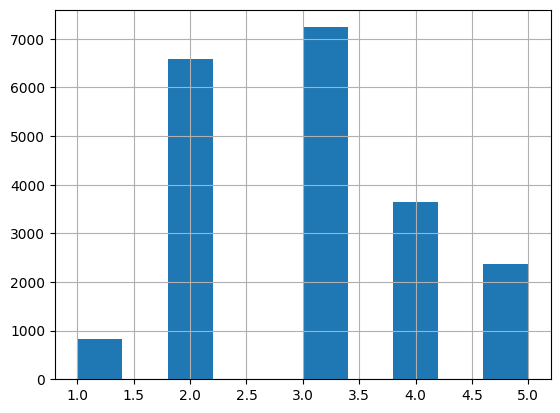

In [32]:
df["income_cat"].hist()

plt.show()

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
str_train,str_test = train_test_split(df,test_size = 0.2, stratify = df["income_cat"] , random_state = 42)

In [35]:
str_test["income_cat"].value_counts(sort = False) 

income_cat
1     165
2    1316
3    1447
4     728
5     472
Name: count, dtype: int64

In [36]:
train_set, test_set = train_test_split(df, test_size=0.2,
                                       random_state=42)

In [37]:
ov = df["income_cat"].value_counts(sort=False)/len(df)
st = str_test["income_cat"].value_counts(sort = False)/len(str_test) 
sim = test_set["income_cat"].value_counts(sort = False)/len(test_set)

pd.DataFrame({"overall":ov,
    "stratified":st,
    "simple":sim,
     "e_st%":((st - ov)/ov )*100,
     "e_sim%":((sim - ov)/ov )*100               
                    })

,overall,stratified,simple,e_st%,e_sim%
income_cat,,,,,
1,0.039826,0.039971,0.042393,0.364964,6.447689
2,0.318847,0.318798,0.307413,-0.015195,-3.586081
3,0.350581,0.350533,0.345203,-0.013820,-1.533997
4,0.176308,0.176357,0.184109,0.027480,4.424292
5,0.114438,0.114341,0.120882,-0.084674,5.630821


In [38]:
for set_ in (str_train,str_test):
    set_.drop("income_cat", axis=1, inplace=True)

In [39]:
for set_ in (train_set, test_set):
    set_.drop("income_cat", axis=1, inplace=True)

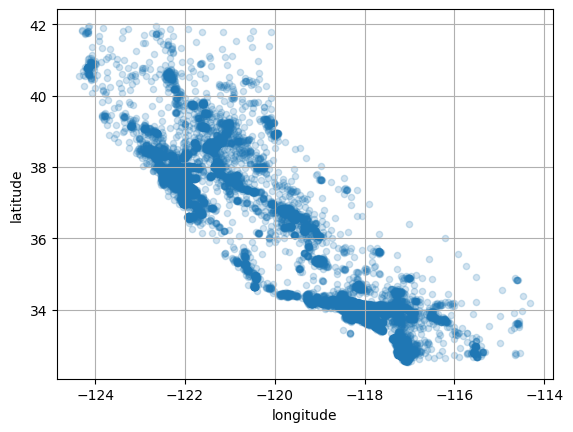

In [40]:
df.plot(kind="scatter", x="longitude", y="latitude", grid=True , alpha = 0.2)
plt.show()

In [41]:
housing = train_set.drop("median_house_value", axis=1)
housing_labels = train_set["median_house_value"].copy()

In [42]:
housing_num = housing.select_dtypes([np.number])

In [43]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
imputer.fit(housing_num)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [44]:
imputer.statistics_

array([-118.49  ,   34.25  ,   29.    , 2129.    ,  437.    , 1169.    ,
        411.    ,    3.5246])

In [45]:
X = imputer.transform(housing_num)

In [46]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)

In [47]:
housing_tr.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
dtype: int64

In [48]:
X = imputer.transform(housing_num)

In [49]:
X

array([[-1.1722e+02,  3.2750e+01,  3.4000e+01, ...,  2.6540e+03,
         1.0720e+03,  4.5878e+00],
       [-1.1703e+02,  3.2690e+01,  1.0000e+01, ...,  6.9800e+02,
         1.6700e+02,  4.6648e+00],
       [-1.2227e+02,  3.7740e+01,  2.8000e+01, ...,  2.9740e+03,
         1.4840e+03,  3.6875e+00],
       ...,
       [-1.1933e+02,  3.6280e+01,  1.6000e+01, ...,  1.0770e+03,
         5.2000e+02,  2.1250e+00],
       [-1.1719e+02,  3.4080e+01,  2.2000e+01, ...,  1.5670e+03,
         4.9400e+02,  2.6536e+00],
       [-1.1886e+02,  3.4220e+01,  2.2000e+01, ...,  6.7300e+02,
         1.9500e+02,  6.2708e+00]])

In [51]:
housing_cat = test_set.select_dtypes(object)
housing_cat

,ocean_proximity
20046,INLAND
3024,<1H OCEAN
15663,NEAR OCEAN
20484,<1H OCEAN
9814,<1H OCEAN
...,...
15362,INLAND
16623,NEAR BAY
18086,INLAND
2144,<1H OCEAN


In [53]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

a = encoder.fit_transform(housing_cat)

In [ ]:
print(a)

[[0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 ...
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]


In [61]:
encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'NEAR BAY', 'NEAR OCEAN'], dtype=object)]

In [69]:
b = pd.get_dummies(housing_cat,dtype=int)

In [70]:
b

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
20046,0,1,0,0
3024,1,0,0,0
15663,0,0,0,1
20484,1,0,0,0
9814,1,0,0,0
...,...,...,...,...
15362,0,1,0,0
16623,0,0,1,0
18086,0,1,0,0
2144,1,0,0,0


In [71]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1,1))
housing_num_minmax = scaler.fit_transform(housing_num)



In [72]:
housing_num_minmax

array([[ 0.42031873, -0.95536663,  0.29411765, ..., -0.85139718,
        -0.6477553 , -0.4361595 ],
       [ 0.45816733, -0.96811902, -0.64705882, ..., -0.96104151,
        -0.94540372, -0.42553896],
       [-0.58565737,  0.10520723,  0.05882353, ..., -0.83345946,
        -0.51225127, -0.5603371 ],
       ...,
       [ 0.        , -0.20510096, -0.41176471, ..., -0.93979652,
        -0.82930439, -0.77585137],
       [ 0.42629482, -0.67268863, -0.17647059, ..., -0.91232938,
        -0.83785562, -0.70294203],
       [ 0.0936255 , -0.64293305, -0.17647059, ..., -0.96244289,
        -0.9361947 , -0.20402477]])

In [73]:
from sklearn.preprocessing import StandardScaler

scaler2 = StandardScaler()
housing_num_stdSca = scaler2.fit_transform(housing_num)

In [78]:
housing_num_stdSca = pd.DataFrame(housing_num_stdSca, columns=housing_num.columns,
                          index=housing_num.index)

housing_num_stdSca

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14196,1.172993,-1.350415,0.428537,1.570557,1.367982,1.081011,1.507507,0.379698
8267,1.268028,-1.378536,-1.473509,-0.809439,-0.898930,-0.643842,-0.878707,0.420068
17445,-1.352939,0.988349,-0.046974,1.994289,2.427309,1.363196,2.593828,-0.092320
14265,-1.127856,0.758691,-0.284730,0.646558,0.227353,0.661262,0.394820,0.682999
2271,1.793222,-1.083261,-1.632013,-1.117906,-1.178707,-1.203802,-1.255755,-1.255560
...,...,...,...,...,...,...,...,...
11284,-1.402957,1.082087,1.617317,-0.777706,-0.741107,-0.731143,-0.804879,-1.335305
11964,0.592779,-0.816108,0.507789,-0.400173,-0.499590,-0.613860,-0.496385,1.421304
5390,0.117604,0.304062,-0.997998,-0.005374,-0.028512,-0.309630,0.052048,-0.911522
860,1.187999,-0.727057,-0.522486,-0.078641,0.038443,0.122465,-0.016506,-0.634382


In [79]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

In [80]:
age_simil_35

array([[9.04837418e-01],
       [7.18778174e-28],
       [7.44658307e-03],
       ...,
       [2.09879105e-16],
       [4.57533877e-08],
       [4.57533877e-08]])

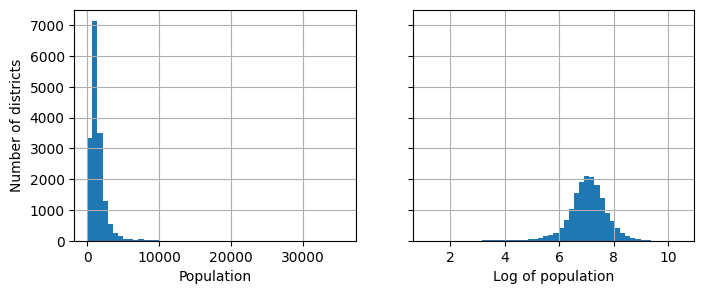

In [81]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["population"].hist(ax=axs[0], bins=50)
housing["population"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")

plt.show()

In [84]:
from sklearn.linear_model import LinearRegression
target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())

model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)
some_new_data = housing[["median_income"]].iloc[:5]

scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)

In [85]:
predictions

array([[236054.10114638],
       [239237.69758773],
       [198830.83002753],
       [259972.41986486],
       [107097.77256737]])

In [86]:
scaled_predictions

array([[ 0.26085752],
       [ 0.28859244],
       [-0.06342485],
       [ 0.46922957],
       [-0.86258658]])

In [87]:
from sklearn.compose import TransformedTargetRegressor
model = TransformedTargetRegressor(LinearRegression(),transformer=StandardScaler())

model.fit(housing[["median_income"]],housing_labels)

predictions = model.predict(some_new_data)


In [88]:
predictions

array([236054.10114638, 239237.69758773, 198830.83002753, 259972.41986486,
       107097.77256737])

In [99]:

from sklearn.preprocessing import FunctionTransformer

transformer = FunctionTransformer(np.log , inverse_func= np.exp)

In [117]:
log_pop = transformer.transform(housing[["population"]])
type(log_pop)

pandas.core.frame.DataFrame

In [130]:

ab = pd.concat([log_pop, housing["population"]], axis=1)
ab.columns = ["log","normal"]
ab


,log,normal
14196,7.883823,2654.0
8267,6.548219,698.0
17445,7.997663,2974.0
14265,7.686162,2178.0
2271,4.143135,63.0
...,...,...
11284,6.395262,599.0
11964,6.595781,732.0
5390,6.981935,1077.0
860,7.356918,1567.0


array([[<Axes: title={'center': 'log'}>,
        <Axes: title={'center': 'normal'}>]], dtype=object)

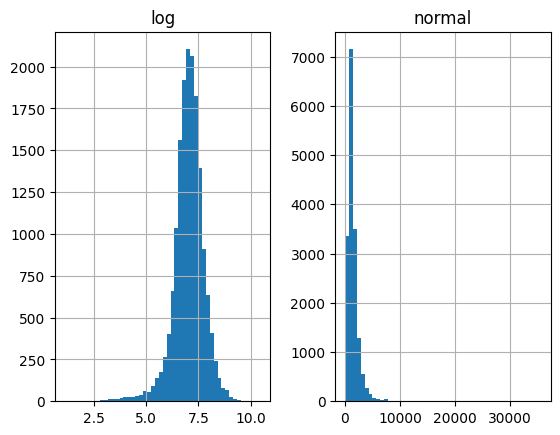

In [132]:
ab.hist(bins = 50)

In [133]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("standerdize",StandardScaler())
])

In [134]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)

In [137]:
type(housing_num)

pandas.core.frame.DataFrame

In [138]:
num_pipeline.get_feature_names_out()

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

In [139]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
                "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

cat_pipeline = make_pipeline(
                    SimpleImputer(strategy="most_frequent"),
                    OneHotEncoder(handle_unknown="ignore"))

preprocessing = ColumnTransformer([
    ("num",num_pipeline,num_attribs),
    ("cat",cat_pipeline,cat_attribs)]
)

In [145]:
from sklearn.compose import make_column_selector , make_column_transformer

preprocessing = make_column_transformer((num_pipeline , make_column_selector(dtype_include=np.number)),
                                         (cat_pipeline, make_column_selector(dtype_include=object)))

In [146]:
housing_prepared = preprocessing.fit_transform(housing)

In [150]:
pd.DataFrame(housing_prepared , columns=preprocessing.get_feature_names_out() , index=housing.index)

,pipeline-1__longitude,pipeline-1__latitude,pipeline-1__housing_median_age,pipeline-1__total_rooms,pipeline-1__total_bedrooms,pipeline-1__population,pipeline-1__households,pipeline-1__median_income,pipeline-2__ocean_proximity_<1H OCEAN,pipeline-2__ocean_proximity_INLAND,pipeline-2__ocean_proximity_ISLAND,pipeline-2__ocean_proximity_NEAR BAY,pipeline-2__ocean_proximity_NEAR OCEAN
14196,1.172993,-1.350415,0.428537,1.570557,1.376799,1.081011,1.507507,0.379698,0.0,0.0,0.0,0.0,1.0
8267,1.268028,-1.378536,-1.473509,-0.809439,-0.900718,-0.643842,-0.878707,0.420068,0.0,0.0,0.0,0.0,1.0
17445,-1.352939,0.988349,-0.046974,1.994289,2.441082,1.363196,2.593828,-0.092320,0.0,0.0,0.0,1.0,0.0
14265,-1.127856,0.758691,-0.284730,0.646558,0.230833,0.661262,0.394820,0.682999,1.0,0.0,0.0,0.0,0.0
2271,1.793222,-1.083261,-1.632013,-1.117906,-1.181804,-1.203802,-1.255755,-1.255560,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-1.402957,1.082087,1.617317,-0.777706,-0.742156,-0.731143,-0.804879,-1.335305,0.0,0.0,0.0,1.0,0.0
11964,0.592779,-0.816108,0.507789,-0.400173,-0.499510,-0.613860,-0.496385,1.421304,1.0,0.0,0.0,0.0,0.0
5390,0.117604,0.304062,-0.997998,-0.005374,-0.026228,-0.309630,0.052048,-0.911522,0.0,1.0,0.0,0.0,0.0
860,1.187999,-0.727057,-0.522486,-0.078641,0.041040,0.122465,-0.016506,-0.634382,0.0,1.0,0.0,0.0,0.0
